# Ground State Energy of the Ising Model

## Data Loading \& Imports

In [54]:
chain_file = "data/1D/ising_chain_8.txt"
small_nearest_file = "data/2D/4x4_EA.txt"
nearest_neighbor_file = "data/2D/10x10_EA.txt"

In [55]:
import os
import json
import numpy as np
import networkx as nx
from natsort import natsorted
import gurobipy as gp
from math import sqrt
import matplotlib.pyplot as plt

In [56]:
import numpy as np
import matplotlib
from scipy.optimize import minimize
from qiskit import QuantumCircuit, circuit
from qiskit_aer import AerSimulator
import qiskit_nature.second_q as sq
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_algorithms.optimizers import SPSA

from qiskit.quantum_info import Statevector, SparsePauliOp
from qiskit.visualization import plot_histogram

from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

In [57]:
# Backend and transpiler setup
service = QiskitRuntimeService(name="mane4960-dedicated")

qpu = service.backend("ibm_rensselaer")
sim = AerSimulator()
qpu_sim = AerSimulator.from_backend(qpu)

pm = generate_preset_pass_manager(backend=qpu_sim, optimization_level=3)

## Function Definitions

In [58]:
"""
Data Loading Helper Function
"""
def read_nxgraph(filename):
    """
    Reads a graph from a file in a specified text format.
    """
    graph = nx.Graph()
    with open(filename, 'r') as file:
        line = file.readline()
        is_first_line = True
        while line is not None and line != '':
            if '//' not in line:
                if is_first_line:
                    strings = line.split(" ")
                    num_nodes = int(strings[0])
                    nodes = list(range(num_nodes))
                    graph.add_nodes_from(nodes)
                    is_first_line = False
                else:
                    node1, node2, weight_str = line.split()
                    # Edge weight coupling J_ij
                    graph.add_edge(int(node1) - 1, int(node2) - 1, weight=float(weight_str))
            line = file.readline()
    return graph

In [59]:
"""
Visual Helper Functions
"""
def lattice_layout(graph, rows, cols):
    """
    Return the positions of each node in a lattice shape
    """
    pos = {}
    for i, node in enumerate(graph.nodes):
        row = i // cols
        col = i % cols
        pos[node] = (col, -row)
    return pos

def draw_graph(graph, rows, cols):
    """
    Draws the graph using the lattice format
    """
    pos = lattice_layout(graph, rows, cols)
    plt.figure(figsize=(8, 6))

    nx.draw(graph, pos, with_labels=True, node_size=5, node_color='lightblue', font_size=8)
    plt.show()

In [60]:
"""
Gurobi Helper Function
"""
def gurobi_ising_solver(graph):
    """
    Initializes Gurobi solver with Hamiltonian objective and minimizes it
    """
    # Create QUBO matrix
    nodes = len(list(graph.nodes))
    J = nx.to_numpy_array(graph)

    # Construct gurobi model
    model = gp.Model("ising_solver")

    # Set time limit 1 hr
    model.setParam('TimeLimit', 3600)
    
    # Set to MIP
    model.setParam("MIPGap", 0.0)

    # Create variable for each vertex
    x = model.addVars(nodes, vtype=gp.GRB.BINARY)

    # Hamiltonian/objective calculation (2*x-1 to convert to spin +1,-1 not binary 0,1)
    objective = gp.quicksum(
        -J[i, j] * (2 * x[i] - 1) * (2 * x[j] - 1)
        for i in range(nodes) for j in range(i+1, nodes) if J[i, j] != 0.0
    )
    model.setObjective(objective, gp.GRB.MINIMIZE)
    
    # Solve
    model.optimize()
    obj_val = model.ObjVal
    obj_bnd = model.ObjBound
    solution = ""
    for i in range(nodes):
        solution += f"{int(x[i].X)}"

    return obj_val, solution

In [69]:
"""
Qiskit Helper Functions
"""
def build_paulis(graph):
    """
    Constructs Ising Hamiltonian in the quantum circuit, replacing spins with Pauli Z: 
    Σ J_ij * x_i * x_j --> Σ J_ij * (Z_i ⊗ Z_j)
    (Not negative in this case because linear ramping maximizes instead of minimizes)
    """
    pauli_list = []
    for edge in list(graph.edges()):
        weight_list = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight_list['weight']))
    return pauli_list

def build_ansatz(cost_hamiltonian, reps):
    """
    Creates the ansatz for QAOA using Qiskit's built-in function
    """
    ansatz = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=reps)
    ansatz.measure_all()
    return ansatz

def linear_ramp(p, delta_gamma=0.6, delta_beta=0.3):
    """
    Calculates gamma and beta parameters according to linear ramp
    https://arxiv.org/abs/2405.09169
    """
    gammas = []
    betas = []
    
    for i in range(p):
        beta = (1 - (i / p)) * delta_beta
        gamma = ((i + 1) / p) * delta_gamma
        
        gammas.append(gamma)
        betas.append(beta)
        
    return gammas, betas

def normalize_hamiltonian(hamiltonian):
    """
    Normalizes the Hamiltonian by the maximum weight for linear ramping
    https://arxiv.org/abs/2405.09169
    """
    max_coeff = np.max(np.abs(hamiltonian.coeffs))
    return hamiltonian / max_coeff

def calculate_energy(bitstring, graph):
    """
    Recalculate energy given the Qiskit solution to compare with classical/ground truth energy
    """
    energy = 0

    # Calculate Hamiltonian
    for node1, node2, data in graph.edges(data=True):
        # Convert binary to spin (0 --> 1, 1 --> -1)
        s1 = 1 if bitstring[node1] == '0' else -1
        s2 = 1 if bitstring[node2] == '0' else -1
        
        energy += -data['weight'] * (s1 * s2)
        
    return energy

# 1. Initial 2x2 Example

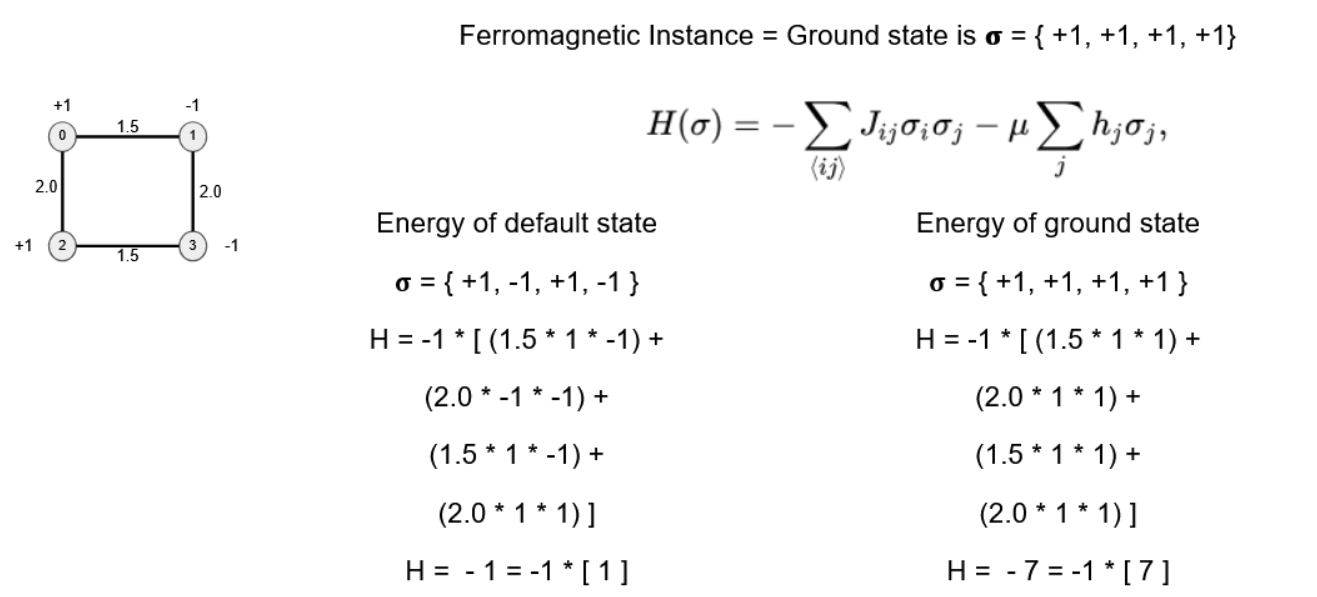

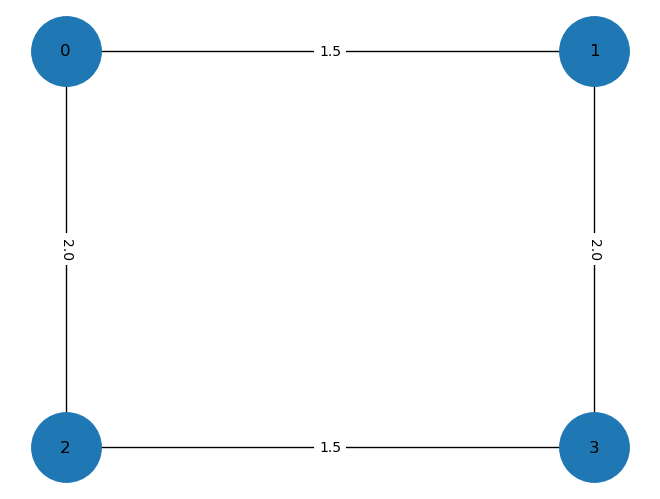

In [62]:
G = nx.Graph()
G.add_node(0, pos=(0,0))
G.add_node(1, pos=(1,0))
G.add_node(2, pos=(0,-1))
G.add_node(3, pos=(1,-1))
G.add_edge(0, 1, weight=1.5)
G.add_edge(1, 3, weight=2.0)
G.add_edge(0, 2, weight=2.0)
G.add_edge(2, 3, weight=1.5)

pos=nx.get_node_attributes(G,'pos')
nx.draw(G, pos, node_size=2500, with_labels='True')
labels = nx.get_edge_attributes(G,'weight')
nx.draw_networkx_edge_labels(G,pos,edge_labels=labels)
plt.show()

In [63]:
initial_paulis = build_paulis(G)
cost_hamiltonian = SparsePauliOp.from_sparse_list(initial_paulis, 4)
cost_hamiltonian = normalize_hamiltonian(cost_hamiltonian)
print(cost_hamiltonian)

SparsePauliOp(['IIZZ', 'IZIZ', 'ZIZI', 'ZZII'],
              coeffs=[0.75+0.j, 1.  +0.j, 1.  +0.j, 0.75+0.j])


In [64]:
p = 50
delta_gamma = 0.6
delta_beta = 0.3
ansatz = build_ansatz(cost_hamiltonian, reps=p)
#ansatz.decompose().decompose().draw(output="mpl", fold=False, idle_wires=False, scale=1)

In [65]:
ansatz.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(β[2]), ParameterVectorElement(β[3]), ParameterVectorElement(β[4]), ParameterVectorElement(β[5]), ParameterVectorElement(β[6]), ParameterVectorElement(β[7]), ParameterVectorElement(β[8]), ParameterVectorElement(β[9]), ParameterVectorElement(β[10]), ParameterVectorElement(β[11]), ParameterVectorElement(β[12]), ParameterVectorElement(β[13]), ParameterVectorElement(β[14]), ParameterVectorElement(β[15]), ParameterVectorElement(β[16]), ParameterVectorElement(β[17]), ParameterVectorElement(β[18]), ParameterVectorElement(β[19]), ParameterVectorElement(β[20]), ParameterVectorElement(β[21]), ParameterVectorElement(β[22]), ParameterVectorElement(β[23]), ParameterVectorElement(β[24]), ParameterVectorElement(β[25]), ParameterVectorElement(β[26]), ParameterVectorElement(β[27]), ParameterVectorElement(β[28]), ParameterVectorElement(β[29]), ParameterVectorElement(β[30]), ParameterVectorElement(β[31]), Par

In [13]:
candidate_circuit = pm.run(ansatz)
gammas, betas = linear_ramp(p, delta_gamma, delta_beta)
param_dict = {}
for i, gamma_val in enumerate(gammas):
    param_obj = [k for k in ansatz.parameters if f'γ[{i}]' in k.name][0]
    param_dict[param_obj] = gamma_val

for i, beta_val in enumerate(betas):
    param_obj = [k for k in ansatz.parameters if f'β[{i}]' in k.name][0]
    param_dict[param_obj] = beta_val

In [14]:
param_dict

{ParameterVectorElement(γ[0]): 0.012,
 ParameterVectorElement(γ[1]): 0.024,
 ParameterVectorElement(γ[2]): 0.036,
 ParameterVectorElement(γ[3]): 0.048,
 ParameterVectorElement(γ[4]): 0.06,
 ParameterVectorElement(γ[5]): 0.072,
 ParameterVectorElement(γ[6]): 0.084,
 ParameterVectorElement(γ[7]): 0.096,
 ParameterVectorElement(γ[8]): 0.108,
 ParameterVectorElement(γ[9]): 0.12,
 ParameterVectorElement(γ[10]): 0.132,
 ParameterVectorElement(γ[11]): 0.144,
 ParameterVectorElement(γ[12]): 0.156,
 ParameterVectorElement(γ[13]): 0.168,
 ParameterVectorElement(γ[14]): 0.18,
 ParameterVectorElement(γ[15]): 0.192,
 ParameterVectorElement(γ[16]): 0.20400000000000001,
 ParameterVectorElement(γ[17]): 0.216,
 ParameterVectorElement(γ[18]): 0.22799999999999998,
 ParameterVectorElement(γ[19]): 0.24,
 ParameterVectorElement(γ[20]): 0.252,
 ParameterVectorElement(γ[21]): 0.264,
 ParameterVectorElement(γ[22]): 0.276,
 ParameterVectorElement(γ[23]): 0.288,
 ParameterVectorElement(γ[24]): 0.3,
 ParameterVec

In [15]:
optimized_circuit = candidate_circuit.assign_parameters(param_dict)
sampler = Sampler(mode=sim)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

D:\Anaconda\envs\Gurobi\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


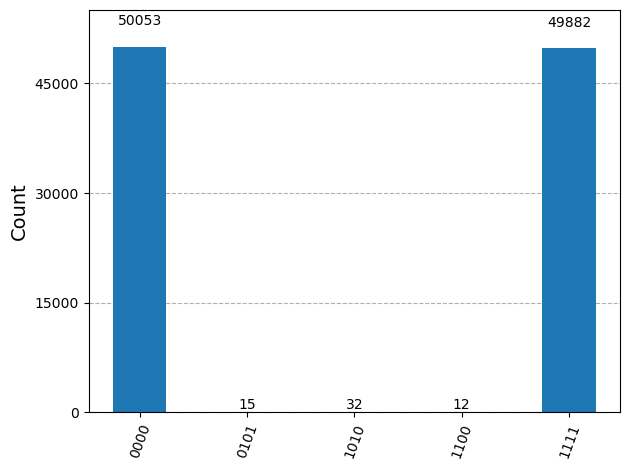

In [16]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:5])
plot_histogram(top_5)

In [17]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], G)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

Energy of 0000: -7.0


# 2. 1D Chain

## 2.1. Gurobi

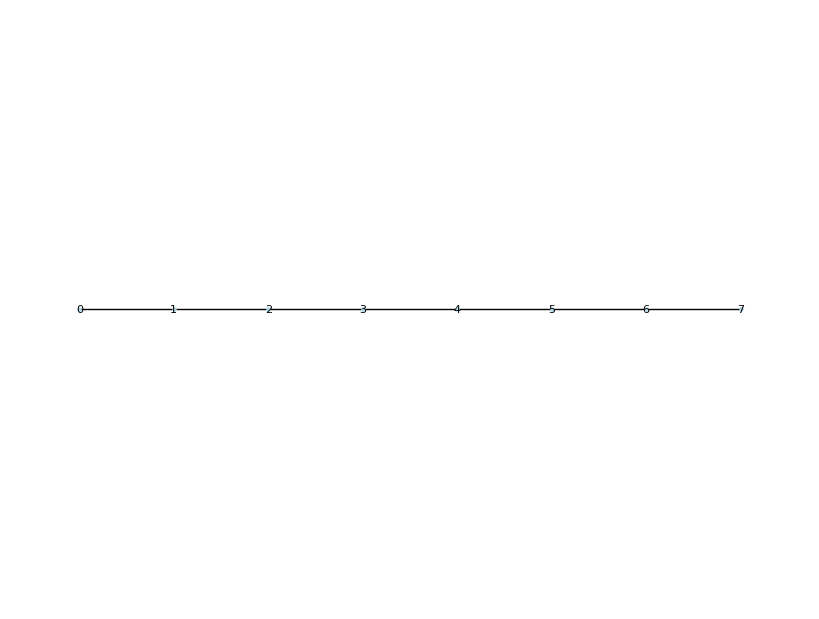

In [18]:
chain_graph = read_nxgraph(chain_file)
draw_graph(chain_graph, 8, 8)

In [19]:
gurobi_obj, gurobi_sol = gurobi_ising_solver(chain_graph)

Restricted license - for non-production use only - expires 2027-11-29
Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0

Optimize a model with 0 rows, 8 columns and 0 nonzeros (Min)
Model fingerprint: 0x2dc2c2e4
Model has 8 linear objective coefficients and an objective constant of -2.3651481425574987e+00
Model has 7 quadratic objective terms
Variable types: 0 continuous, 8 integer (8 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [4e-01, 2e+00]
  QObjective range [7e-01, 6e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective -2.3651481
Found heuristic solution: objective -2.3651481
P

In [20]:
print("Minimum Energy State:", gurobi_obj)
print("Solution (spin configuration):", gurobi_sol)

Minimum Energy State: -2.3651481425575005
Solution (spin configuration): 11111111


## 2.2. Qiskit

In [21]:
paulis = build_paulis(chain_graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, 8)
cost_hamiltonian = normalize_hamiltonian(cost_hamiltonian)
print(cost_hamiltonian)

SparsePauliOp(['IIIIIIZZ', 'IIIIIZZI', 'IIIIZZII', 'IIIZZIII', 'IIZZIIII', 'IZZIIIII', 'ZZIIIIII'],
              coeffs=[0.57893631+0.j, 1.        +0.j, 0.69429039+0.j, 0.41971719+0.j,
 0.20373581+0.j, 0.12819027+0.j, 0.2585782 +0.j])


In [22]:
ansatz = build_ansatz(cost_hamiltonian, reps=p)
#ansatz.decompose().decompose().draw(output="mpl", fold=False, idle_wires=False, scale=1)

In [23]:
candidate_circuit = pm.run(ansatz)
gammas, betas = linear_ramp(p, delta_gamma, delta_beta)
param_dict = {}
for i, gamma_val in enumerate(gammas):
    param_obj = [k for k in ansatz.parameters if f'γ[{i}]' in k.name][0]
    param_dict[param_obj] = gamma_val

for i, beta_val in enumerate(betas):
    param_obj = [k for k in ansatz.parameters if f'β[{i}]' in k.name][0]
    param_dict[param_obj] = beta_val

In [24]:
optimized_circuit = candidate_circuit.assign_parameters(param_dict)
sampler = Sampler(mode=qpu)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

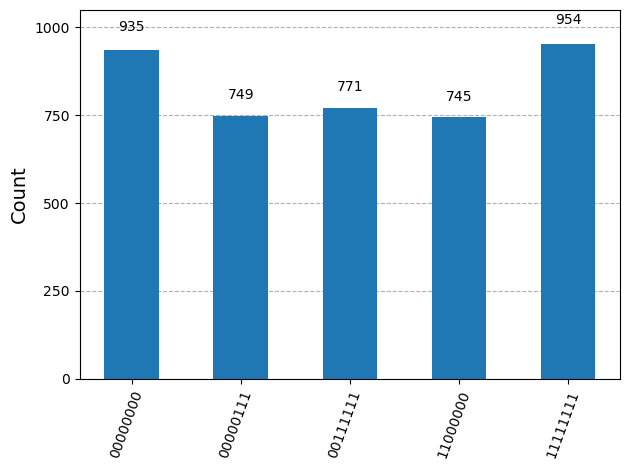

In [25]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:5])
plot_histogram(top_5)

In [26]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], chain_graph)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

Energy of 11111111: -2.3651481425574987


In [27]:
print(f"Gurobi: {gurobi_obj}, {gurobi_sol}")
print(f"Qiskit: {energy}, {most_frequent_string[::-1]}")

Gurobi: -2.3651481425575005, 11111111
Qiskit: -2.3651481425574987, 11111111


# 3. 4x4 2D Lattice
## 3.1 Gurobi

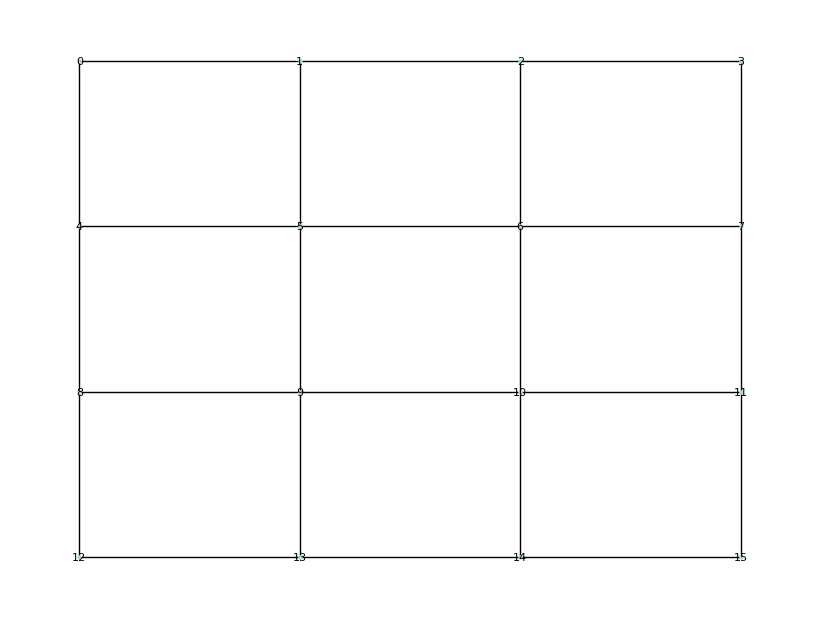

In [28]:
small_nearest_graph = read_nxgraph(small_nearest_file)
draw_graph(small_nearest_graph, 4, 4)

In [29]:
gurobi_obj, gurobi_sol = gurobi_ising_solver(small_nearest_graph)

Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0

Optimize a model with 0 rows, 16 columns and 0 nonzeros (Min)
Model fingerprint: 0x4b5c5a5f
Model has 16 linear objective coefficients and an objective constant of -2.5307574172301228e-01
Model has 24 quadratic objective terms
Variable types: 0 continuous, 16 integer (16 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [1e-01, 4e+00]
  QObjective range [6e-01, 8e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective -0.2530757
Found heuristic solution: objective -0.2530757
Found heuristic solution: objective -10.9381498
Presolve removed 0

In [30]:
print("Minimum Energy State:", gurobi_obj)
print("Solution (spin configuration):", gurobi_sol)

Minimum Energy State: -10.93814981250091
Solution (spin configuration): 0111011011100100


## 3.2. Qiskit

In [31]:
paulis = build_paulis(small_nearest_graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, 16)
cost_hamiltonian = normalize_hamiltonian(cost_hamiltonian)
print(cost_hamiltonian)

SparsePauliOp(['IIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIZIIIZ', 'IIIIIIIIIIIIIZZI', 'IIIIIIIIIIZIIIZI', 'IIIIIIIIIIIIZZII', 'IIIIIIIIIZIIIZII', 'IIIIIIIIZIIIZIII', 'IIIIIIIIIIZZIIII', 'IIIIIIIZIIIZIIII', 'IIIIIIIIIZZIIIII', 'IIIIIIZIIIZIIIII', 'IIIIIIIIZZIIIIII', 'IIIIIZIIIZIIIIII', 'IIIIZIIIZIIIIIII', 'IIIIIIZZIIIIIIII', 'IIIZIIIZIIIIIIII', 'IIIIIZZIIIIIIIII', 'IIZIIIZIIIIIIIII', 'IIIIZZIIIIIIIIII', 'IZIIIZIIIIIIIIII', 'ZIIIZIIIIIIIIIII', 'IIZZIIIIIIIIIIII', 'IZZIIIIIIIIIIIII', 'ZZIIIIIIIIIIIIII'],
              coeffs=[-0.16599396+0.j,  0.44074981+0.j,  0.60162676+0.j,  0.93673743+0.j,
  0.97794588+0.j,  0.49644487+0.j, -0.17192735+0.j, -1.        +0.j,
 -0.39542531+0.j, -0.37323702+0.j,  0.38473324+0.j, -0.43921249+0.j,
  0.57869103+0.j, -0.17168073+0.j, -0.70664986+0.j, -0.81550936+0.j,
  0.75295054+0.j,  0.7893939 +0.j, -0.79372955+0.j, -0.10423679+0.j,
  0.07180924+0.j, -0.62762315+0.j, -0.83010146+0.j,  0.81737798+0.j])


In [32]:
p = 10
ansatz = build_ansatz(cost_hamiltonian, reps=p)
#ansatz.decompose().decompose().draw(output="mpl", fold=False, idle_wires=False, scale=1)

In [36]:
candidate_circuit = pm.run(ansatz)
gammas, betas = linear_ramp(p, delta_gamma, delta_beta)
param_dict = {}
for i, gamma_val in enumerate(gammas):
    param_obj = [k for k in ansatz.parameters if f'γ[{i}]' in k.name][0]
    param_dict[param_obj] = gamma_val

for i, beta_val in enumerate(betas):
    param_obj = [k for k in ansatz.parameters if f'β[{i}]' in k.name][0]
    param_dict[param_obj] = beta_val

In [37]:
optimized_circuit = candidate_circuit.assign_parameters(param_dict)
sampler = Sampler(mode=qpu)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

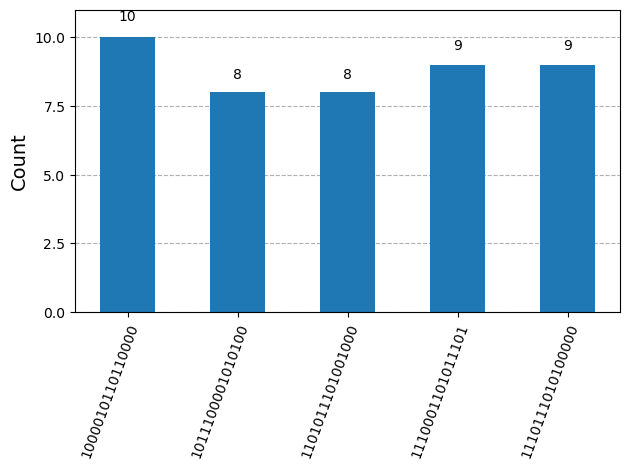

In [38]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:5])
plot_histogram(top_5)

In [39]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], small_nearest_graph)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

Energy of 0000110110100001: 0.5604703402633102


In [40]:
print(f"Gurobi: {gurobi_obj}, {gurobi_sol}")
print(f"Qiskit: {energy}, {most_frequent_string[::-1]}")

Gurobi: -10.93814981250091, 0111011011100100
Qiskit: 0.5604703402633102, 0000110110100001


# 4. 10x10 2D Lattice

## 4.1 Gurobi

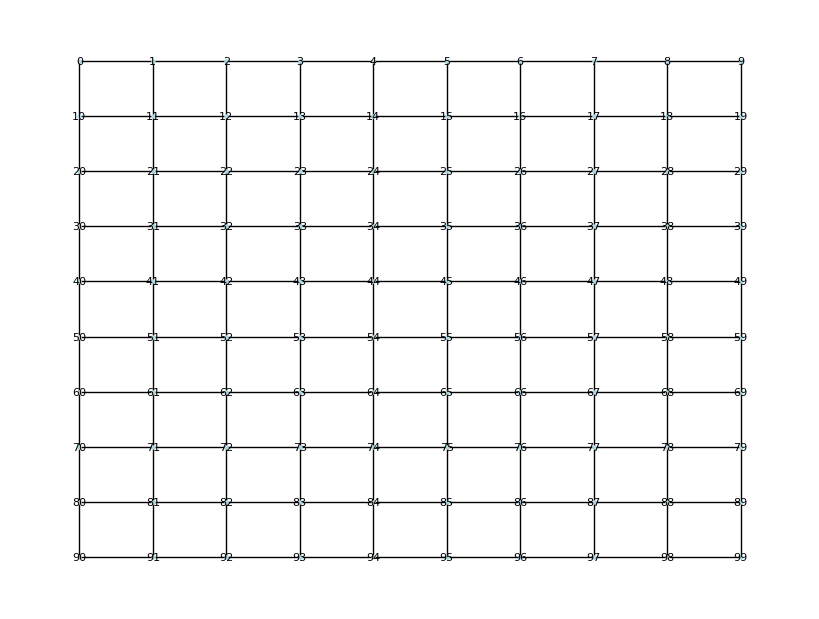

In [66]:
nearest_neighbor_graph = read_nxgraph(nearest_neighbor_file)
draw_graph(nearest_neighbor_graph, 10, 10)

In [67]:
gurobi_obj, gurobi_sol = gurobi_ising_solver(nearest_neighbor_graph)

Set parameter TimeLimit to value 3600
Set parameter MIPGap to value 0
Gurobi Optimizer version 13.0.0 build v13.0.0rc1 (win64 - Windows 10.0 (19045.2))

CPU model: AMD Ryzen 7 5800H with Radeon Graphics, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 16 logical processors, using up to 16 threads

Non-default parameters:
TimeLimit  3600
MIPGap  0

Optimize a model with 0 rows, 100 columns and 0 nonzeros (Min)
Model fingerprint: 0xdf4d9182
Model has 100 linear objective coefficients and an objective constant of 7.7091450069921965e+00
Model has 180 quadratic objective terms
Variable types: 0 continuous, 100 integer (100 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [3e-04, 7e+00]
  QObjective range [1e-01, 8e+00]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective 7.7091450
Found heuristic solution: objective -77.3311709
Presolve removed 0 rows and 37 columns
Presolve time: 0.03s
Pr

In [68]:
print("Minimum Energy State:", gurobi_obj)
print("Solution (spin configuration):", gurobi_sol)

Minimum Energy State: -78.65040168400627
Solution (spin configuration): 1000110110100111101100001000101011101100010110011001011010100110111011010001010101111111010100011110


## 4.2 Qiskit

In [45]:
paulis = build_paulis(nearest_neighbor_graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(paulis, 100)
cost_hamiltonian = normalize_hamiltonian(cost_hamiltonian)
print(cost_hamiltonian)

SparsePauliOp(['IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIZ', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIZI', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIZII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZIIIIIIIIIZIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIZZIIII', 'IIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIIII

In [46]:
ansatz = build_ansatz(cost_hamiltonian, reps=p)
#ansatz.decompose().decompose().draw(output="mpl", idle_wires=False, scale=1)

In [47]:
candidate_circuit = pm.run(ansatz)
gammas, betas = linear_ramp(p, delta_gamma, delta_beta)
param_dict = {}
for i, gamma_val in enumerate(gammas):
    param_obj = [k for k in ansatz.parameters if f'γ[{i}]' in k.name][0]
    param_dict[param_obj] = gamma_val

for i, beta_val in enumerate(betas):
    param_obj = [k for k in ansatz.parameters if f'β[{i}]' in k.name][0]
    param_dict[param_obj] = beta_val

In [48]:
optimized_circuit = candidate_circuit.assign_parameters(param_dict)
sampler = Sampler(mode=qpu)

sampler.options.default_shots = 100000

# Set simple error suppression/mitigation options
sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit)
job = sampler.run([pub], shots=int(1e5))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()

D:\Anaconda\envs\Gurobi\Lib\site-packages\qiskit\visualization\counts_visualization.py:412: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


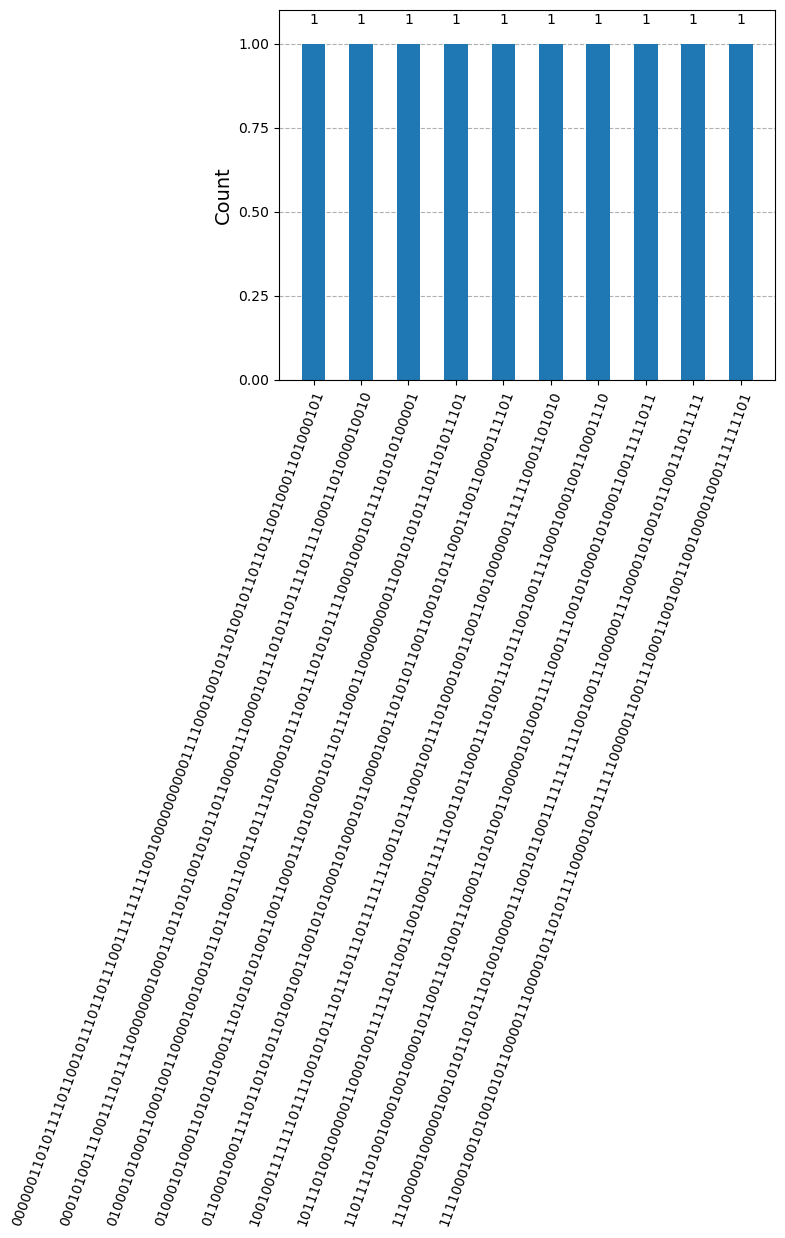

In [49]:
top_5 = dict(sorted(counts_bin.items(), key=lambda item: item[1], reverse=True)[:10])
plot_histogram(top_5)

In [50]:
most_frequent_string = max(counts_bin, key=counts_bin.get)
energy = calculate_energy(most_frequent_string[::-1], nearest_neighbor_graph)
print(f"Energy of {most_frequent_string[::-1]}: {energy}")

Energy of 1011111110001000010011001001100011100110000011111100100001111010110100001110000110101001010010001111: 9.29633094522899


In [51]:
print(f"Gurobi: {gurobi_obj}, {gurobi_sol}")
print(f"Qiskit: {energy}, {most_frequent_string[::-1]}")

Gurobi: -78.65040168400627, 1000110110100111101100001000101011101100010110011001011010100110111011010001010101111111010100011110
Qiskit: 9.29633094522899, 1011111110001000010011001001100011100110000011111100100001111010110100001110000110101001010010001111
